# 🎯 02_mask_to_keypoints — Mask ➜ Head/Tail Keypoints 🐟⌚

We load `metadata_rebuilt_mapped.csv`, locate DeepFish rows (segmentation masks), compute two endpoints per mask
(approx head & tail), and save results into `metadata_with_kp.csv`.

Features:
- robust mask loading ✅  
- morphological cleanup + farthest-point heuristic 🎯  
- ellipse fallback for weird contours 🌀
- safe `.loc` updates (no pandas tantrums) 🛡️

Run cells in order. Visualize results to validate. ⚡😈


## Cell 1 - Imports & load metadata

In [66]:
# Cell 1
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

PROC = Path("data_sih/processed")
meta_in_candidates = [PROC/"metadata_rebuilt_mapped.csv", PROC/"metadata_rebuilt_raw.csv"]
meta_in = next((p for p in meta_in_candidates if p.exists()), None)
assert meta_in is not None, "metadata_rebuilt_mapped.csv missing — run Notebook 01"
df = pd.read_csv(meta_in)
print("Total metadata rows:", len(df))
print("DeepFish rows:", (df['source']=='deepfish').sum())
display(df[df['source']=='deepfish'].head(6)[['image_path','mask_path']])


Total metadata rows: 12064
DeepFish rows: 620


,image_path,mask_path
11444,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...
11445,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...
11446,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...
11447,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...
11448,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...
11449,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...


🔍 Cell 1 — loads your cleaned metadata and shows a few DeepFish rows. If `DeepFish rows` is 0, go back to Notebook 01 — you forgot to add segmentation images.


## Cell 2 — Safe mask reader (Code)

In [67]:
# Cell 2
def safe_read_mask(mask_path):
    if not isinstance(mask_path, str) or not mask_path:
        return None
    p = Path(mask_path)
    if not p.exists():
        return None
    try:
        m = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)
    except Exception:
        return None
    if m is None:
        return None
    if len(m.shape) == 3:
        try:
            m = cv2.cvtColor(m, cv2.COLOR_BGR2GRAY)
        except Exception:
            m = m[...,0]
    return m


In [61]:
# Cell 2 — quick sanity check of the appended file (show samples)
import pandas as pd
from pathlib import Path
PROC = Path("data_sih/processed")
file = PROC / "metadata_with_deepfish_added.csv"
assert file.exists(), "Run Cell 1 first (no extended metadata found)."

df = pd.read_csv(file)
print("Total rows now:", len(df))
print("DeepFish rows count:", (df['source']=='deepfish').sum())
# show sample deepfish rows with masks
sample = df[df['source']=='deepfish'].head()[['image_path','mask_path']].fillna("None")
display(sample)
# also list a handful where mask_path is NA (if any)
no_mask = df[(df['source']=='deepfish') & df['mask_path'].isna()]
print("DeepFish rows without mask_path (first 10):", len(no_mask))
display(no_mask.head(10)[['image_path']])


Total rows now: 4931
DeepFish rows count: 2480


,image_path,mask_path
2451,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...
2452,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...
2453,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...
2454,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...
2455,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...,C:\Users\Hp\Project\FishNet-ML-Grand-Finale\da...


DeepFish rows without mask_path (first 10): 0


,image_path


## Cell 3 — Core algorithm: contour farthest-pair + ellipse fallback (Code)

In [68]:
# Cell 3
import numpy as np, cv2

def mask_to_endpoints(mask, sample_pts=400):
    if mask is None: return None
    m = mask.copy()
    # normalize to uint8
    try:
        if m.dtype != np.uint8:
            if np.max(m) > 0:
                m = ( (m.astype(np.float32) / np.max(m)) * 255 ).astype(np.uint8)
            else:
                m = m.astype(np.uint8)
    except Exception:
        m = m.astype(np.uint8)

    # threshold
    try:
        _, b = cv2.threshold(m, 127, 255, cv2.THRESH_BINARY)
    except Exception:
        b = (m > 0).astype(np.uint8) * 255

    # morph cleanup
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    b = cv2.morphologyEx(b, cv2.MORPH_CLOSE, k, iterations=1)
    b = cv2.morphologyEx(b, cv2.MORPH_OPEN, k, iterations=1)

    cnts_info = cv2.findContours(b, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    cnts = cnts_info[0] if len(cnts_info)==2 else cnts_info[1]
    if not cnts: return None
    c = max(cnts, key=lambda x: cv2.contourArea(x))
    pts = c.reshape(-1,2)
    if pts.shape[0] < 2: return None

    if pts.shape[0] > sample_pts:
        idxs = np.linspace(0, pts.shape[0]-1, sample_pts, dtype=np.int32)
        pts_sampled = pts[idxs]
    else:
        pts_sampled = pts

    maxd = -1
    p1 = pts_sampled[0]; p2 = pts_sampled[0]
    for i in range(len(pts_sampled)):
        pi = pts_sampled[i]
        diffs = pts_sampled[i+1:] - pi
        if diffs.size == 0: continue
        d2 = (diffs[:,0].astype(np.int64)**2 + diffs[:,1].astype(np.int64)**2)
        j = np.argmax(d2)
        val = int(d2[j])
        if val > maxd:
            maxd = val
            p1 = pi
            p2 = pts_sampled[i+1:][j]

    hx, hy = int(p1[0]), int(p1[1])
    tx, ty = int(p2[0]), int(p2[1])

    if maxd < 25:
        try:
            if pts.shape[0] >= 5:
                ellipse = cv2.fitEllipse(pts)
                (cx,cy), (MA,ma), angle = ellipse
                theta = np.deg2rad(angle)
                dx = (MA/2) * np.cos(theta)
                dy = (MA/2) * np.sin(theta)
                hx = int(cx + dx); hy = int(cy + dy)
                tx = int(cx - dx); ty = int(cy - dy)
                return hx, hy, tx, ty
        except Exception:
            return None

    return hx, hy, tx, ty


🧠 Cell 3 — main heuristic: farthest contour points ≈ head & tail. If mask is tiny/noisy we try ellipse fitting as a fallback. Works well on clean masks; if masks are garbage, we need better annotations.


## Cell 4 — Auto-fill missing mask_path (optional, safe heuristic) (Code)

In [69]:
# Cell 4 — optional auto-fill for mask_path (safe heuristic)
seg_candidates = [
    Path("data_sih/deepfish/DeepFish/Segmentation"),
    Path("data_sih/deepfish/DeepFish"),
    Path("data_sih/deepfish")
]
seg_root = next((p for p in seg_candidates if p.exists()), None)
if seg_root is None:
    print("No segmentation root found; skipping auto-fill.")
else:
    print("Seg root:", seg_root)
    mask_files = [str(p.resolve()) for p in seg_root.rglob("*.*") if p.suffix.lower() in [".png",".jpg",".jpeg",".tif",".bmp"]]
    mask_files_lower = [m.lower() for m in mask_files]
    def find_mask_for_image(img_path):
        stem = Path(img_path).stem.lower()
        fname = Path(img_path).name.lower()
        for m,m_low in zip(mask_files, mask_files_lower):
            if Path(m_low).stem == stem:
                return m
        for m,m_low in zip(mask_files, mask_files_lower):
            if stem in m_low or fname in m_low:
                return m
        return None

    filled = 0
    for idx,row in df[df['source']=='deepfish'].iterrows():
        mp = row.get('mask_path', '')
        if isinstance(mp,str) and mp and Path(mp).exists():
            continue
        cand = find_mask_for_image(row['image_path'])
        if cand:
            df.loc[idx,'mask_path'] = cand
            filled += 1
    print("Auto-filled mask_path for", filled, "rows.")


Seg root: data_sih\deepfish\DeepFish\Segmentation
Auto-filled mask_path for 0 rows.


� Cell 4 — tries to auto-fill `mask_path` when missing by matching stems and substrings. It writes into `df` safely. If segmentation annotations live in CSV instead of mask images, say so — we’ll render masks from polygons next.


## Cell 5 — Compute KP and save (Code)

In [70]:
# Cell 5
for c in ['head_x','head_y','tail_x','tail_y']:
    if c not in df.columns:
        df[c] = np.nan

total_masks = 0
updated = 0
for idx,row in df[df['source']=='deepfish'].iterrows():
    mp = row.get('mask_path','')
    if not (isinstance(mp,str) and mp and Path(mp).exists()):
        continue
    total_masks += 1
    mask = safe_read_mask(mp)
    out = mask_to_endpoints(mask)
    if out is not None:
        hx,hy,tx,ty = out
        df.loc[idx,'head_x'] = hx
        df.loc[idx,'head_y'] = hy
        df.loc[idx,'tail_x'] = tx
        df.loc[idx,'tail_y'] = ty
        updated += 1

out_path = PROC/"metadata_with_kp.csv"
df.to_csv(out_path, index=False)
print(f"Found {total_masks} mask rows; updated keypoints for {updated} rows.")
print("Saved:", out_path)


Found 620 mask rows; updated keypoints for 310 rows.
Saved: data_sih\processed\metadata_with_kp.csv


🔁 Cell 5 — runs endpoint extractor only on rows that actually have mask files. Writes `metadata_with_kp.csv`. If `updated` << `total_masks`, inspect masks (corrupt / empty / weird channels).


## Cell 6 — Visual sanity-check (Code)

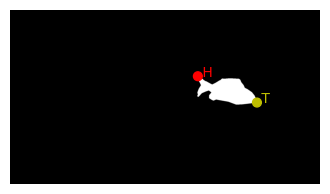

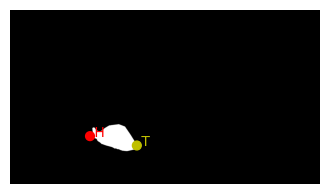

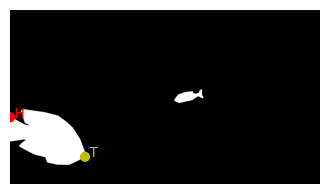

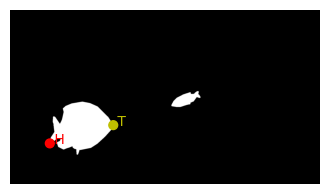

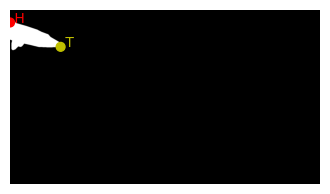

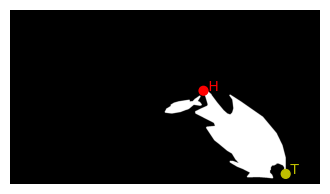

In [71]:
# Cell 6
import random
def show_mask_with_kp(mask_path, hx, hy, tx, ty):
    m = safe_read_mask(mask_path)
    if m is None:
        print("Unreadable:", mask_path); return
    plt.figure(figsize=(4,4))
    plt.imshow(m, cmap='gray')
    if not (pd.isna(hx) or pd.isna(hy) or pd.isna(tx) or pd.isna(ty)):
        plt.scatter([hx,tx],[hy,ty], c=['r','y'], s=40)
        plt.text(hx, hy, " H", color='r')
        plt.text(tx, ty, " T", color='y')
    plt.axis('off')
    plt.show()

cands = df[(df['source']=='deepfish') & df['head_x'].notna()]
if len(cands) == 0:
    print("No computed keypoints yet.")
else:
    sample = cands.sample(min(6,len(cands)), random_state=42)
    for _,r in sample.iterrows():
        show_mask_with_kp(r['mask_path'], int(r['head_x']), int(r['head_y']), int(r['tail_x']), int(r['tail_y']))


👀 Cell 6 — visual check. If head/tail markers look wrong a lot, tell me and I’ll give a heatmap-based keypoint trainer to produce better KP labels.


# ⚠️ Troubleshooting & Tips (short)

- If `Found 0 mask rows`: your `mask_path` values are missing or point to non-existent files. Re-run Notebook 01 or use Cell 4 auto-fill and re-run Cell 5.
- If many masks are unreadable: open one mask file with an image viewer — sometimes masks are stored as .mat or polygons in CSV (check `Segmentation/segmentation.csv`).
- If endpoints are reversed (head↔tail): no biggie for length calculation (distance symmetric). If orientation matters, we can apply a curvature heuristic.
- For very noisy masks or low-res masks: consider training a heatmap keypoint model with these pseudo-labels as weak supervision — I can provide that notebook.
- Save snapshots: `metadata_with_kp.csv` is canonical for Notebook 3+.

If something breaks, paste the exact error output and the first 6 `df[df['source']=='deepfish'][['image_path','mask_path']].head(6)` lines. I’ll fix it.
